<a href="https://colab.research.google.com/github/mclaramoorais/Banco-de-Dados/blob/main/Chocolate_Sales_Analytics_Atividade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
produtos = pd.read_csv("produtos.csv")
clientes = pd.read_csv("clientes.csv")
vendas = pd.read_csv("vendas.csv")
calendario = pd.read_csv("calendario.csv")
lojas = pd.read_csv("lojas.csv")

print(produtos.head())
print(clientes.head())
print(vendas.head())
print(calendario.head())
print(lojas.head())

  product_id           product_name    brand category  cocoa_percent  weight_g
0      P0001    White Chocolate 80%     Mars  Truffle             80       120
1      P0002     Dark Chocolate 70%  Cadbury  Praline             70       100
2      P0003  Truffle Chocolate 70%  Hershey  Praline             70       120
3      P0004     Milk Chocolate 50%     Mars  Praline             50        80
4      P0005    White Chocolate 70%  Ferrero    White             70        50
  customer_id  age  gender  loyalty_member   join_date
0     C000001   40    Male               1  2025-05-21
1     C000002   47    Male               0  2021-12-26
2     C000003   58  Female               1  2022-09-13
3     C000004   25  Female               0  2025-02-27
4     C000005   43    Male               0  2023-08-31
      order_id  order_date product_id store_id customer_id  quantity  \
0  0RD00000001  2023-01-07      P0080     S093     C040749         5   
1  0RD00000002  2023-10-22      P0173     S065     C

In [ ]:
print(produtos.info())
print(clientes.info())
print(vendas.info())
print(calendario.info())
print(lojas.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     200 non-null    object
 1   product_name   200 non-null    object
 2   brand          200 non-null    object
 3   category       200 non-null    object
 4   cocoa_percent  200 non-null    int64 
 5   weight_g       200 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 9.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     50000 non-null  object
 1   age             50000 non-null  int64 
 2   gender          50000 non-null  object
 3   loyalty_member  50000 non-null  int64 
 4   join_date       50000 non-null  object
dtypes: int64(2), object(3)
memory usage: 1.9+ MB
None
<class 'pandas.core.frame.

In [ ]:
print(produtos.isnull().sum())
print(clientes.isnull().sum())
print(vendas.isnull().sum())
print(calendario.isnull().sum())
print(lojas.isnull().sum())

product_id       0
product_name     0
brand            0
category         0
cocoa_percent    0
weight_g         0
dtype: int64
customer_id       0
age               0
gender            0
loyalty_member    0
join_date         0
dtype: int64
order_id       0
order_date     0
product_id     0
store_id       0
customer_id    0
quantity       0
unit_price     0
discount       0
revenue        0
cost           0
profit         0
dtype: int64
date           0
year           0
month          0
day            0
week           0
day_of_week    0
dtype: int64
store_id      0
store_name    0
city          0
country       0
store_type    0
dtype: int64


In [ ]:
df = vendas.merge(produtos, on="product_id")

df = df.merge(lojas, on="store_id")

df = df.merge(clientes, on="customer_id")

df = df.merge(calendario, left_on="order_date", right_on="date")

In [ ]:
resultado = (
    df
    .groupby("category")["revenue"]
    .sum()
    .reset_index()
)

print(resultado)

  category     revenue
0     Dark  5298123.27
1     Milk  3280368.19
2  Praline  6665641.32
3  Truffle  3924343.24
4    White  6070172.20


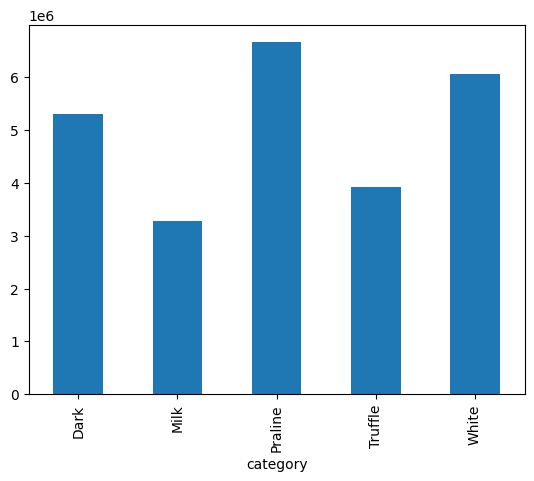

In [ ]:
import matplotlib.pyplot as plt

vendas_produto = df.groupby("category")["revenue"].sum()

vendas_produto.plot.bar()

plt.show()

In [ ]:
resultado_regiao = df.groupby("country")["revenue"].sum()

print(resultado_regiao.sort_values(ascending=False))

country
Canada       5036623.01
UK           4777585.16
USA          4298447.49
France       4296611.25
Australia    3798165.48
Germany      3031215.83
Name: revenue, dtype: float64


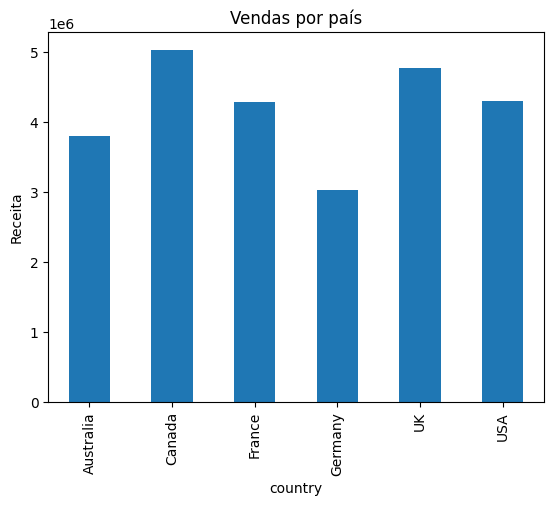

In [ ]:
import matplotlib.pyplot as plt

vendas_regiao = df.groupby("country")["revenue"].sum()

vendas_regiao.plot(kind="bar")

plt.title("Vendas por país")
plt.ylabel("Receita")

plt.show()

In [ ]:
resultado_mes = df.groupby("month")["revenue"].sum()

print(resultado_mes.sort_index())

month
1     2157534.34
2     1960211.41
3     2147152.30
4     2061387.64
5     2141643.83
6     2064064.90
7     2148545.89
8     2149425.20
9     2087740.32
10    2126795.06
11    2057294.68
12    2136852.65
Name: revenue, dtype: float64


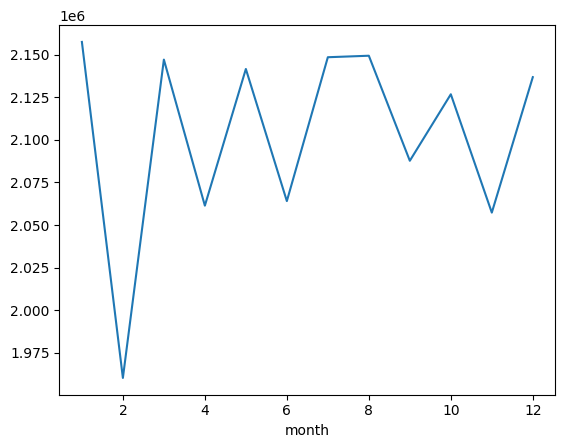

In [ ]:
import matplotlib.pyplot as plt

vendas_mes = df.groupby("month")["revenue"].sum()

vendas_mes.plot()

plt.show()

In [ ]:
resultado_lucro = df.groupby("category")["profit"].sum()

print(resultado_lucro.sort_values(ascending=False))

category
Praline    2665242.79
White      2428117.37
Dark       2120672.08
Truffle    1569202.54
Milk       1312407.13
Name: profit, dtype: float64


In [ ]:
top_produtos = (
    df.groupby("product_name")["quantity"]
    .sum()
    .nlargest(10)
)

print(top_produtos)

product_name
Dark Chocolate 50%       208996
Truffle Chocolate 80%    193431
Praline Chocolate 50%    162670
Milk Chocolate 70%       162335
Dark Chocolate 60%       149346
White Chocolate 50%      149170
White Chocolate 90%      134217
Truffle Chocolate 90%    133692
White Chocolate 80%      133171
Praline Chocolate 70%    132564
Name: quantity, dtype: int64
